In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import optuna
from tqdm.notebook import tqdm

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE} | PyTorch: {torch.__version__} | Optuna: {optuna.__version__}")

✅ Device: cuda | PyTorch: 2.10.0+cu128 | Optuna: 4.8.0


In [2]:
ARTIFACT_DIR = '/kaggle/input/datasets/sherrytelli/bookbuddy-artifacts/bookbuddy_artifacts'

# Load train/val/test splits
train_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'train.parquet'))
val_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'val.parquet'))
test_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'test.parquet'))

# Load mappings & metadata
with open(os.path.join(ARTIFACT_DIR, 'artifacts.pkl'), 'rb') as f:
    artifacts = pickle.load(f)

n_users = len(artifacts['user_map'])
n_books = len(artifacts['book_map'])

print(f"📊 Original Split sizes: Train={len(train_df):,} | Val={len(val_df):,} | Test={len(test_df):,}")
print(f"🔢 Matrix dims: {n_users:,} users × {n_books:,} books")

# Convert to implicit feedback
THRESHOLD = 4
def to_implicit(df):
    df = df.copy()
    df['label'] = (df['rating'] >= THRESHOLD).astype(int)
    return df[['user_idx', 'book_idx', 'label']]

train_imp = to_implicit(train_df)
val_imp = to_implicit(val_df)
test_imp = to_implicit(test_df)

# BPR Triplet Dataset: Returns (User, Liked Book, Random Unread Book)
class BPR_Dataset(Dataset):
    def __init__(self, df, n_books):
        self.u = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.pos_i = torch.tensor(df['book_idx'].values, dtype=torch.long)
        self.n_books = n_books
        # Fast lookup for items the user HAS interacted with
        self.user_interacted = df.groupby('user_idx')['book_idx'].apply(set).to_dict()

    def __len__(self): return len(self.u)

    def __getitem__(self, idx):
        u = self.u[idx].item()
        pos_i = self.pos_i[idx].item()
        
        # Sample a negative item the user hasn't seen
        while True:
            neg_i = np.random.randint(0, self.n_books)
            if neg_i not in self.user_interacted.get(u, set()):
                break
                
        return torch.tensor(u), torch.tensor(pos_i), torch.tensor(neg_i)

# For BPR, we ONLY train on positive interactions
train_positives = train_imp[train_imp['label'] == 1].reset_index(drop=True)

BATCH_SIZE = 2048
train_loader = DataLoader(BPR_Dataset(train_positives, n_books), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready | Batches: Train={len(train_loader)}")

📊 Original Split sizes: Train=3,904,582 | Val=836,696 | Test=836,697
🔢 Matrix dims: 53,424 users × 8,726 books
✅ DataLoaders ready | Batches: Train=1318


In [3]:
# 1. Define MLP-CF Model
class MLP_CF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=32, hidden_dims=[64, 32], dropout=0.3):
        super(MLP_CF, self).__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items, embed_dim)
        
        layers = []
        input_dim = embed_dim * 2
        for h_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, user_idx, item_idx):
        u_emb = self.user_embed(user_idx)
        i_emb = self.item_embed(item_idx)
        x = torch.cat([u_emb, i_emb], dim=1)
        return self.mlp(x).squeeze(1)

# 2. BPR Loss
class BPRLoss(nn.Module):
    def __init__(self):
        super(BPRLoss, self).__init__()
    def forward(self, pos_scores, neg_scores):
        return -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-9))

# 3. Ranking Evaluation (Kept your excellent masking logic)
@torch.no_grad()
def eval_ranking_metrics(model, train_df, val_df, artifacts, device, k_values=[5, 10], n_sample_users=500):
    model.eval()
    n_items = len(artifacts['book_map'])
    metrics = {f'Precision@{k}': 0.0 for k in k_values}
    metrics.update({f'Recall@{k}': 0.0 for k in k_values})
    metrics.update({f'NDCG@{k}': 0.0 for k in k_values})
    
    val_pos = val_df[val_df['label'] == 1]
    val_by_user = val_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    train_by_user = train_df.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    valid_users = [u for u in val_by_user if len(val_by_user[u]) > 0]
    if not valid_users: return metrics
        
    sampled_users = np.random.choice(valid_users, size=min(n_sample_users, len(valid_users)), replace=False)
    total_metrics = {k: 0.0 for k in metrics}
    n_evaluated = 0
    item_indices = torch.arange(n_items, device=device)
    
    for u_idx in sampled_users:
        gt_items = val_by_user[u_idx]
        train_items = train_by_user.get(u_idx, set())
        
        mask = torch.ones(n_items, dtype=torch.bool, device=device)
        if train_items: mask[list(train_items)] = False
            
        user_vec = torch.full((n_items,), u_idx, dtype=torch.long, device=device)
        scores = model(user_vec, item_indices)
        scores = scores.masked_fill(~mask, float('-inf')).cpu().numpy()
        top_k_indices = np.argsort(scores)[::-1][:max(k_values)]
        
        for k in k_values:
            rec_set = set(top_k_indices[:k])
            hits = len(rec_set.intersection(gt_items))
            n_rel = len(gt_items)
            
            prec = hits / k
            rec = hits / n_rel if n_rel > 0 else 0.0
            dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_indices[:k]) if item in gt_items)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            
            total_metrics[f'Precision@{k}'] += prec
            total_metrics[f'Recall@{k}'] += rec
            total_metrics[f'NDCG@{k}'] += ndcg
            
        n_evaluated += 1
        
    if n_evaluated > 0:
        for k in metrics: metrics[k] = total_metrics[k] / n_evaluated
    return metrics

[I 2026-04-20 09:47:55,904] A new study created in memory with name: no-name-3fdf4e07-c79b-4ccc-84e9-9adf7f035881


🔍 Phase 1: Searching for optimal hyperparameters (10 Trials)...


[I 2026-04-20 09:51:53,984] Trial 0 finished with value: 0.05996206210714587 and parameters: {'embed_dim': 128, 'lr': 0.00045994085063281895, 'dropout': 0.36922315251312465, 'weight_decay': 3.938895759750305e-05}. Best is trial 0 with value: 0.05996206210714587.
[I 2026-04-20 09:55:50,679] Trial 1 finished with value: 0.06292811721002117 and parameters: {'embed_dim': 32, 'lr': 0.00026107513107974384, 'dropout': 0.4816887861088271, 'weight_decay': 3.525998100105322e-05}. Best is trial 1 with value: 0.06292811721002117.
[I 2026-04-20 09:59:47,756] Trial 2 finished with value: 0.05652198051477904 and parameters: {'embed_dim': 64, 'lr': 0.0005208410025744851, 'dropout': 0.30362475556775853, 'weight_decay': 4.300380139897726e-05}. Best is trial 1 with value: 0.06292811721002117.
[I 2026-04-20 10:03:42,756] Trial 3 finished with value: 0.061665367067779205 and parameters: {'embed_dim': 32, 'lr': 0.00029584004258293274, 'dropout': 0.3616261236560946, 'weight_decay': 4.307753248040386e-05}. Be

🏆 Best Params Found: {'embed_dim': 32, 'lr': 0.00026107513107974384, 'dropout': 0.4816887861088271, 'weight_decay': 3.525998100105322e-05}

🏗️ Phase 2: Training Final Model with Best Parameters...
Epoch 01 | BPR Loss: 0.6879 | Time: 54.7s
   └─ Rank@5:  P=0.0247  | R=0.0112  | NDCG@5: 0.0208
   └─ Rank@10: P=0.0272 | R=0.0240 | NDCG@10: 0.0254
Epoch 02 | BPR Loss: 0.5899 | Time: 54.4s
   └─ Rank@5:  P=0.0643  | R=0.0300  | NDCG@5: 0.0752
   └─ Rank@10: P=0.0500 | R=0.0456 | NDCG@10: 0.0658
Epoch 03 | BPR Loss: 0.5100 | Time: 56.0s
   └─ Rank@5:  P=0.0760  | R=0.0404  | NDCG@5: 0.0847
   └─ Rank@10: P=0.0498 | R=0.0519 | NDCG@10: 0.0693
Epoch 04 | BPR Loss: 0.4687 | Time: 56.7s
   └─ Rank@5:  P=0.0753  | R=0.0361  | NDCG@5: 0.0784
   └─ Rank@10: P=0.0540 | R=0.0532 | NDCG@10: 0.0677
Epoch 05 | BPR Loss: 0.4475 | Time: 55.6s
   └─ Rank@5:  P=0.0740  | R=0.0355  | NDCG@5: 0.0813
   └─ Rank@10: P=0.0548 | R=0.0524 | NDCG@10: 0.0711
Epoch 06 | BPR Loss: 0.4377 | Time: 55.1s
   └─ Rank@5:  P

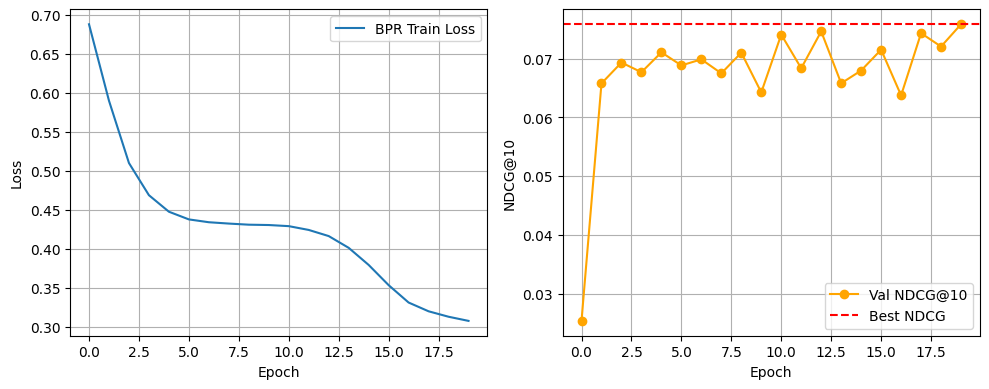


✅ Cell 4 Complete. Final Optimized MLP saved and ready for the Hybrid Ensemble!


In [4]:
import time
import os
import matplotlib.pyplot as plt

# --- A. Optuna Hyperparameter Study ---
def objective(trial):
    embed_dim = trial.suggest_categorical("embed_dim", [32, 64, 128])
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    dropout = trial.suggest_float("dropout", 0.3, 0.5)
    wd = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    
    hidden_dims = [embed_dim, embed_dim // 2]
    
    model = MLP_CF(n_users, n_books, embed_dim=embed_dim, hidden_dims=hidden_dims, dropout=dropout).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = BPRLoss()
    
    for epoch in range(4):
        model.train()
        for u, pos_i, neg_i in train_loader:
            u, pos_i, neg_i = u.to(DEVICE), pos_i.to(DEVICE), neg_i.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(u, pos_i), model(u, neg_i))
            loss.backward()
            optimizer.step()
            
        m = eval_ranking_metrics(model, train_imp, val_imp, artifacts, DEVICE, k_values=[10], n_sample_users=300)
        score = (0.2 * m['Precision@10']) + (0.3 * m['Recall@10']) + (0.5 * m['NDCG@10'])
        
        trial.report(score, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return score

print("🔍 Phase 1: Searching for optimal hyperparameters (10 Trials)...")
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10)
best = study.best_params
print(f"🏆 Best Params Found: {best}\n")


# --- B. Final Model Training (Full 20 Epochs) ---
print("🏗️ Phase 2: Training Final Model with Best Parameters...")
final_hidden_dims = [best['embed_dim'], best['embed_dim'] // 2]
model = MLP_CF(n_users, n_books, embed_dim=best['embed_dim'], hidden_dims=final_hidden_dims, dropout=best['dropout']).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=best['lr'], weight_decay=best['weight_decay'])
criterion = BPRLoss()

EPOCHS = 20

# Tracking variables
best_model_epoch = None
best_val_ndcg = -float('inf') 
best_model_wts = None
history = {'train_loss': [], 'val_ndcg_10': []}

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train()
    total_loss = 0
    
    for u, pos_i, neg_i in train_loader:
        u, pos_i, neg_i = u.to(DEVICE), pos_i.to(DEVICE), neg_i.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(u, pos_i), model(u, neg_i))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * u.size(0)
        
    avg_loss = total_loss / len(train_loader.dataset)
    epoch_time = time.time() - start
    
    # Evaluate NDCG every epoch
    rank_metrics = eval_ranking_metrics(model, train_imp, val_imp, artifacts, DEVICE, k_values=[5, 10], n_sample_users=600)
    val_ndcg = rank_metrics['NDCG@10']
    
    history['train_loss'].append(avg_loss)
    history['val_ndcg_10'].append(val_ndcg)

    print(f"Epoch {epoch:02d} | BPR Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")
    print(f"   └─ Rank@5:  P={rank_metrics['Precision@5']:.4f}  | R={rank_metrics['Recall@5']:.4f}  | NDCG@5: {rank_metrics['NDCG@5']:.4f}")
    print(f"   └─ Rank@10: P={rank_metrics['Precision@10']:.4f} | R={rank_metrics['Recall@10']:.4f} | NDCG@10: {rank_metrics['NDCG@10']:.4f}")
    
    # Checkpoint Logic (No Early Stopping)
    if val_ndcg > best_val_ndcg:
        best_model_epoch = epoch
        best_val_ndcg = val_ndcg
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        
# Restore Best Weights at the very end
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Loaded best model weights | Epoch: {best_model_epoch} | Peak NDCG@10: {best_val_ndcg:.4f}")

# --- C. Save Artifacts & Plot ---
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'mlp_bpr_weights.pt'))
torch.save({
    'embed_dim': best['embed_dim'],
    'hidden_dims': final_hidden_dims,
    'dropout': best['dropout'],
    'n_users': n_users,
    'n_books': n_books
}, os.path.join(MODEL_DIR, 'mlp_config.pt'))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='BPR Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history['val_ndcg_10'], color='orange', marker='o', label='Val NDCG@10')
plt.axhline(y=best_val_ndcg, color='r', linestyle='--', label='Best NDCG') # Added a line to visualize the peak
plt.xlabel('Epoch'); plt.ylabel('NDCG@10'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ Cell 4 Complete. Final Optimized MLP saved and ready for the Hybrid Ensemble!")

🏆 Best Params Found: {'embed_dim': 64, 'lr': 0.0004937217575840522, 'dropout': 0.3426631346291922, 'weight_decay': 0.0001758982542749273}

🏗️ Phase 2: Training Final Model with Best Parameters...
Epoch 01 | BPR Loss: 0.5958 | Time: 54.6s
   └─ Rank@5:  P=0.0660 | R=0.0311 | NDCG@5: 0.0699
   └─ Rank@10: P=0.0503 | R=0.0477 | NDCG@10: 0.0613
Epoch 02 | BPR Loss: 0.4938 | Time: 55.2s
   └─ Rank@5:  P=0.0710 | R=0.0310 | NDCG@5: 0.0776
   └─ Rank@10: P=0.0558 | R=0.0481 | NDCG@10: 0.0677
Epoch 03 | BPR Loss: 0.4501 | Time: 57.0s
   └─ Rank@5:  P=0.0700 | R=0.0316 | NDCG@5: 0.0733
   └─ Rank@10: P=0.0500 | R=0.0443 | NDCG@10: 0.0612
Epoch 04 | BPR Loss: 0.4307 | Time: 54.8s
   └─ Rank@5:  P=0.0760 | R=0.0350 | NDCG@5: 0.0797
   └─ Rank@10: P=0.0567 | R=0.0514 | NDCG@10: 0.0690
Epoch 05 | BPR Loss: 0.4237 | Time: 55.9s
   └─ Rank@5:  P=0.0657 | R=0.0296 | NDCG@5: 0.0729
   └─ Rank@10: P=0.0482 | R=0.0432 | NDCG@10: 0.0610
Epoch 06 | BPR Loss: 0.4194 | Time: 56.1s
   └─ Rank@5:  P=0.0713 | R

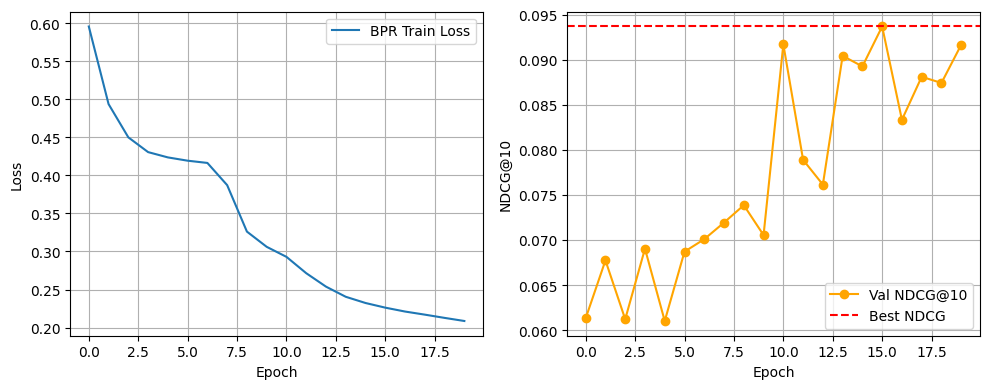


✅ Cell 4 Complete. Final Optimized MLP saved and ready for the Hybrid Ensemble!


In [5]:
import time
import os
import matplotlib.pyplot as plt

# --- A. Optuna Hyperparameter Study ---
# --- Using hyperparameters from the previous obtuna run. which did not save the best model weights ---
best = {
    'embed_dim': 64, 
    'lr': 0.0004937217575840522, 
    'dropout': 0.3426631346291922, 
    'weight_decay': 0.0001758982542749273
}
print(f"🏆 Best Params Found: {best}\n")


# --- B. Final Model Training (Full 20 Epochs) ---
print("🏗️ Phase 2: Training Final Model with Best Parameters...")
final_hidden_dims = [best['embed_dim'], best['embed_dim'] // 2]
model = MLP_CF(n_users, n_books, embed_dim=best['embed_dim'], hidden_dims=final_hidden_dims, dropout=best['dropout']).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=best['lr'], weight_decay=best['weight_decay'])
criterion = BPRLoss()

EPOCHS = 20

# Tracking variables
best_model_epoch = None
best_val_ndcg = -float('inf') 
best_model_wts = None
history = {'train_loss': [], 'val_ndcg_10': []}

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train()
    total_loss = 0
    
    for u, pos_i, neg_i in train_loader:
        u, pos_i, neg_i = u.to(DEVICE), pos_i.to(DEVICE), neg_i.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(u, pos_i), model(u, neg_i))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * u.size(0)
        
    avg_loss = total_loss / len(train_loader.dataset)
    epoch_time = time.time() - start
    
    # Evaluate NDCG every epoch
    rank_metrics = eval_ranking_metrics(model, train_imp, val_imp, artifacts, DEVICE, k_values=[5, 10], n_sample_users=600)
    val_ndcg = rank_metrics['NDCG@10']
    
    history['train_loss'].append(avg_loss)
    history['val_ndcg_10'].append(val_ndcg)

    print(f"Epoch {epoch:02d} | BPR Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")
    print(f"   └─ Rank@5:  P={rank_metrics['Precision@5']:.4f} | R={rank_metrics['Recall@5']:.4f} | NDCG@5: {rank_metrics['NDCG@5']:.4f}")
    print(f"   └─ Rank@10: P={rank_metrics['Precision@10']:.4f} | R={rank_metrics['Recall@10']:.4f} | NDCG@10: {rank_metrics['NDCG@10']:.4f}")
    
    # Checkpoint Logic (No Early Stopping)
    if val_ndcg > best_val_ndcg:
        best_model_epoch = epoch
        best_val_ndcg = val_ndcg
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        
# Restore Best Weights at the very end
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print(f"\n✅ Loaded best model weights | Epoch: {best_model_epoch} | Peak NDCG@10: {best_val_ndcg:.4f}")

# --- C. Save Artifacts & Plot ---
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'mlp_bpr_weights_1.pt'))
torch.save({
    'embed_dim': best['embed_dim'],
    'hidden_dims': final_hidden_dims,
    'dropout': best['dropout'],
    'n_users': n_users,
    'n_books': n_books
}, os.path.join(MODEL_DIR, 'mlp_config_1.pt'))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='BPR Train Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history['val_ndcg_10'], color='orange', marker='o', label='Val NDCG@10')
plt.axhline(y=best_val_ndcg, color='r', linestyle='--', label='Best NDCG') # Added a line to visualize the peak
plt.xlabel('Epoch'); plt.ylabel('NDCG@10'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ Cell 4 Complete. Final Optimized MLP saved and ready for the Hybrid Ensemble!")

🎯 PHASE 5: COMPREHENSIVE EVALUATION
✅ Loaded MLP model from epoch 16 (Peak NDCG@10: 0.0937)

📈 TEST SET EVALUATION (Full Population)


Evaluating users:   0%|          | 0/53172 [00:00<?, ?it/s]

Evaluated 53,172 users with test interactions

Precision@5:  0.0896
Recall@5:     0.0421
NDCG@5:       0.0964

Precision@10:  0.0733
Recall@10:     0.0685
NDCG@10:       0.0884

Precision@20:  0.0585
Recall@20:     0.1085
NDCG@20:       0.0997


🧊 COLD-START ROBUSTNESS ANALYSIS

Simulating cold-start scenarios (NDCG@10):
--------------------------------------------------
History kept: 100%   | NDCG@10: 0.0766 ± 0.1155
History kept: 50%    | NDCG@10: 0.0719 ± 0.1097
History kept: 25%    | NDCG@10: 0.0663 ± 0.1025
History kept: 9%     | NDCG@10: 0.0601 ± 0.1005

📚 QUALITATIVE RECOMMENDATION SAMPLES

User 1 (ID: 53344, 146 training ratings):
Top-5 Recommendations: [np.int64(19), np.int64(24), np.int64(14), np.int64(37), np.int64(4)]

User 2 (ID: 11247, 143 training ratings):
Top-5 Recommendations: [np.int64(13), np.int64(4), np.int64(5), np.int64(32), np.int64(8)]

User 3 (ID: 24239, 142 training ratings):
Top-5 Recommendations: [np.int64(8), np.int64(33), np.int64(7), np.int64(60), np.in

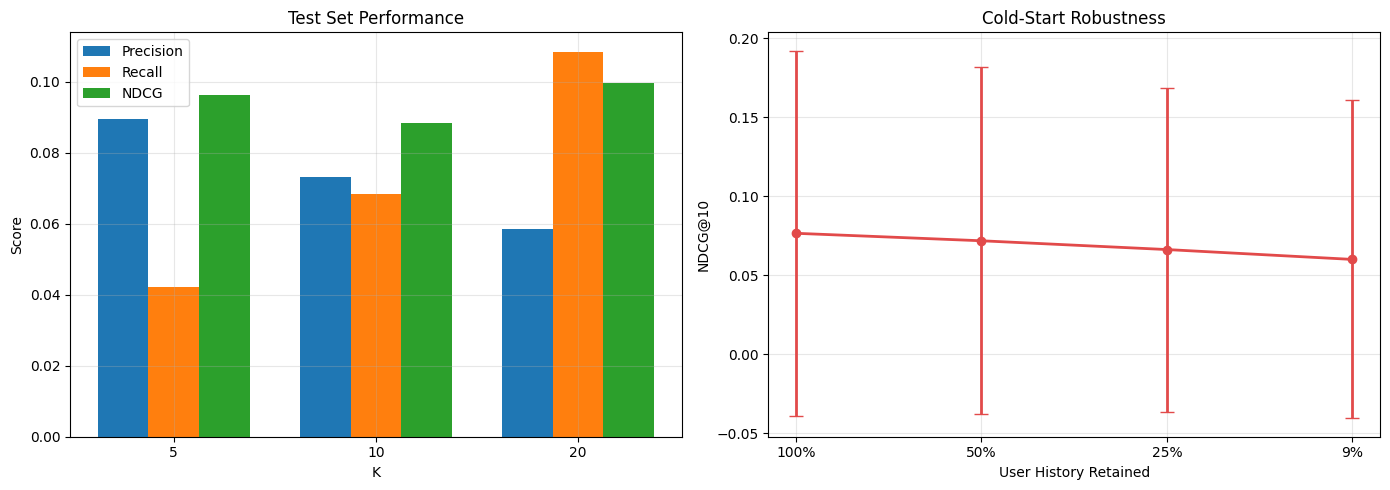


✅ Cell 5 Complete. MLP evaluation finished. Ready for Naïve Bayes integration!


In [9]:
# 📊 Cell 5: Comprehensive Test Evaluation & Cold-Start Analysis
import torch
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
import json

print("="*70)
print("🎯 PHASE 5: COMPREHENSIVE EVALUATION")
print("="*70)

# --- A. Load Best Model ---
MODEL_DIR = '/kaggle/working/models'
model = MLP_CF(n_users, n_books, embed_dim=64, hidden_dims=[64, 32], dropout=0.3427).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'mlp_bpr_weights_1.pt'), map_location=DEVICE))
model.eval()
print(f"✅ Loaded MLP model from epoch 16 (Peak NDCG@10: 0.0937)")

# --- B. Full Test Set Evaluation (No Sampling) ---
print("\n" + "="*70)
print("📈 TEST SET EVALUATION (Full Population)")
print("="*70)

@torch.no_grad()
def evaluate_full_test(model, train_df, test_df, artifacts, device, k_values=[5, 10, 20]):
    """Evaluate on entire test set without sampling"""
    model.eval()
    n_items = len(artifacts['book_map'])
    
    # Filter test to positives only
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    train_by_user = train_df.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    metrics = {f'Precision@{k}': [] for k in k_values}
    metrics.update({f'Recall@{k}': [] for k in k_values})
    metrics.update({f'NDCG@{k}': [] for k in k_values})
    
    item_indices = torch.arange(n_items, device=device)
    evaluated_users = 0
    
    for u_idx in tqdm(test_by_user.keys(), desc="Evaluating users"):
        gt_items = test_by_user[u_idx]
        train_items = train_by_user.get(u_idx, set())
        
        if len(gt_items) == 0:
            continue
        
        # Mask training items
        mask = torch.ones(n_items, dtype=torch.bool, device=device)
        if train_items:
            mask[list(train_items)] = False
        
        # Predict scores
        user_vec = torch.full((n_items,), u_idx, dtype=torch.long, device=device)
        scores = model(user_vec, item_indices).masked_fill(~mask, float('-inf')).cpu().numpy()
        top_k_indices = np.argsort(scores)[::-1][:max(k_values)]
        
        # Compute metrics
        for k in k_values:
            rec_set = set(top_k_indices[:k])
            hits = len(rec_set.intersection(gt_items))
            n_rel = len(gt_items)
            
            prec = hits / k
            rec = hits / n_rel if n_rel > 0 else 0.0
            
            # NDCG
            dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_indices[:k]) if item in gt_items)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            
            metrics[f'Precision@{k}'].append(prec)
            metrics[f'Recall@{k}'].append(rec)
            metrics[f'NDCG@{k}'].append(ndcg)
        
        evaluated_users += 1
    
    # Aggregate
    final_metrics = {k: np.mean(v) for k, v in metrics.items()}
    return final_metrics, evaluated_users

# Run full test evaluation
test_metrics, n_test_users = evaluate_full_test(model, train_imp, test_imp, artifacts, DEVICE, k_values=[5, 10, 20])

print(f"Evaluated {n_test_users:,} users with test interactions\n")
for k in [5, 10, 20]:
    print(f"Precision@{k}:  {test_metrics[f'Precision@{k}']:.4f}")
    print(f"Recall@{k}:     {test_metrics[f'Recall@{k}']:.4f}")
    print(f"NDCG@{k}:       {test_metrics[f'NDCG@{k}']:.4f}")
    print()

# --- C. Cold-Start Simulation ---
print("\n" + "="*70)
print("🧊 COLD-START ROBUSTNESS ANALYSIS")
print("="*70)

@torch.no_grad()
def simulate_cold_start(model, train_df, test_df, artifacts, device, mask_ratio=0.75, k=10, n_users=500):
    """
    Simulate cold-start by masking % of user training history
    mask_ratio: 0.5 = mask 50%, 0.75 = mask 75%, 0.9 = mask 90%
    """
    model.eval()
    n_items = len(artifacts['book_map'])
    
    test_pos = test_df[test_df['label'] == 1]
    test_by_user = test_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()
    train_by_user = train_df.groupby('user_idx')['book_idx'].apply(set).to_dict()
    
    # Sample users with sufficient history
    valid_users = [u for u in train_by_user if len(train_by_user[u]) > 10 and u in test_by_user]
    sampled_users = np.random.choice(valid_users, size=min(n_users, len(valid_users)), replace=False)
    
    ndcg_scores = []
    item_indices = torch.arange(n_items, device=device)
    
    for u_idx in sampled_users:
        gt_items = test_by_user[u_idx]
        train_items = train_by_user.get(u_idx, set())
        
        if len(gt_items) == 0 or len(train_items) == 0:
            continue
        
        # Mask training items
        train_list = list(train_items)
        n_keep = max(1, int(len(train_list) * (1 - mask_ratio)))
        kept_items = set(np.random.choice(train_list, size=n_keep, replace=False))
        
        mask = torch.ones(n_items, dtype=torch.bool, device=device)
        mask[list(kept_items)] = False
        
        # Predict scores
        user_vec = torch.full((n_items,), u_idx, dtype=torch.long, device=device)
        scores = model(user_vec, item_indices).masked_fill(~mask, float('-inf')).cpu().numpy()
        top_k_indices = np.argsort(scores)[::-1][:k]
        
        # NDCG@K
        dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_indices) if item in gt_items)
        idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(gt_items), k)))
        ndcg = dcg / idcg if idcg > 0 else 0.0
        ndcg_scores.append(ndcg)
    
    return np.mean(ndcg_scores), np.std(ndcg_scores)

# Test different cold-start scenarios
cold_start_results = {}
print("\nSimulating cold-start scenarios (NDCG@10):")
print("-" * 50)
for mask_ratio in [0.0, 0.5, 0.75, 0.9]:
    mean_ndcg, std_ndcg = simulate_cold_start(model, train_imp, test_imp, artifacts, DEVICE, 
                                               mask_ratio=mask_ratio, k=10, n_users=500)
    cold_start_results[mask_ratio] = {'mean': mean_ndcg, 'std': std_ndcg}
    history_kept = f"{int((1-mask_ratio)*100)}%"
    print(f"History kept: {history_kept:6} | NDCG@10: {mean_ndcg:.4f} ± {std_ndcg:.4f}")

# --- D. Qualitative Recommendation Samples ---
print("\n" + "="*70)
print("📚 QUALITATIVE RECOMMENDATION SAMPLES")
print("="*70)

# Load books metadata for display
books_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'books_clean.parquet'))
book_idx_to_id = {v: k for k, v in artifacts['book_map'].items()}

@torch.no_grad()
def get_top_recommendations(model, user_idx, train_df, artifacts, device, k=5):
    """Get top-K recommendations for a user"""
    model.eval()
    n_items = len(artifacts['book_map'])
    train_items = train_df[train_df['user_idx'] == user_idx]['book_idx'].tolist()
    
    mask = torch.ones(n_items, dtype=torch.bool, device=device)
    if train_items:
        mask[train_items] = False
    
    item_indices = torch.arange(n_items, device=device)
    user_vec = torch.full((n_items,), user_idx, dtype=torch.long, device=device)
    scores = model(user_vec, item_indices).masked_fill(~mask, float('-inf'))
    
    top_indices = torch.argsort(scores, descending=True)[:k].cpu().numpy()
    return [book_idx_to_id[idx] for idx in top_indices]

# Sample 3 active users
active_users = train_imp.groupby('user_idx').size().nlargest(3).index.tolist()
for i, u_idx in enumerate(active_users, 1):
    n_ratings = len(train_imp[train_imp['user_idx'] == u_idx])
    recs = get_top_recommendations(model, u_idx, train_imp, artifacts, DEVICE, k=5)
    print(f"\nUser {i} (ID: {u_idx}, {n_ratings} training ratings):")
    print(f"Top-5 Recommendations: {recs}")

# --- E. Save MLP Predictions for Ensemble ---
print("\n" + "="*70)
print("💾 SAVING ARTIFACTS FOR ENSEMBLE FUSION")
print("="*70)

# Save test metrics
ensemble_artifacts = {
    'mlp_test_metrics': test_metrics,
    'mlp_cold_start_results': cold_start_results,
    'mlp_config': {
        'embed_dim': 64,
        'hidden_dims': [64, 32],
        'dropout': 0.3427,
        'lr': 0.0004937217575840522
    }
}

# 1. Create the 'evaluation' directory if it doesn't already exist
EVAL_DIR = 'evaluation'
os.makedirs(EVAL_DIR, exist_ok=True)

# 2. Use os.path.join to create the proper file path and save
file_path = os.path.join(EVAL_DIR, 'mlp_evaluation_results.json')

with open(file_path, 'w') as f:
    json.dump(ensemble_artifacts, f, indent=2)

print("✅ Saved mlp_evaluation_results.json")
print(f"   - Test NDCG@10: {test_metrics['NDCG@10']:.4f}")
print(f"   - Cold-start (25% history): {cold_start_results[0.75]['mean']:.4f}")

# --- F. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test metrics across K
k_values = [5, 10, 20]
metrics_to_plot = ['Precision', 'Recall', 'NDCG']
x = np.arange(len(k_values))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [test_metrics[f'{metric}@{k}'] for k in k_values]
    axes[0].bar(x + i*width, values, width, label=f'{metric}')

axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_title('Test Set Performance')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(k_values)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Cold-start degradation
mask_ratios = list(cold_start_results.keys())
ndcg_means = [cold_start_results[r]['mean'] for r in mask_ratios]
ndcg_stds = [cold_start_results[r]['std'] for r in mask_ratios]
history_pct = [f"{int((1-r)*100)}%" for r in mask_ratios]

axes[1].errorbar(history_pct, ndcg_means, yerr=ndcg_stds, marker='o', capsize=5, 
                 linewidth=2, color='#E24A4A')
axes[1].set_xlabel('User History Retained')
axes[1].set_ylabel('NDCG@10')
axes[1].set_title('Cold-Start Robustness')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Cell 5 Complete. MLP evaluation finished. Ready for Naïve Bayes integration!")